In [2]:
install.packages("tinytex")
library(tinytex)
tinytex::install_tinytex()

SyntaxError: invalid syntax (38577265.py, line 3)

In [1]:
import tinytex
tinytex.install()

ModuleNotFoundError: No module named 'tinytex'

# Scholarly Article Classification Pipeline

This notebook contains the complete machine learning pipeline for scholarly article classification using:

- TF-IDF feature extraction (abstract-only)
- Machine learning classifiers
- Cross-validation
- Hyperparameter tuning
- Ensemble learning
- Evaluation metrics

Dataset classes (after BDA + Cloud merge and remap to contiguous 0..4):

- 0  Big Data & Cloud Computing  (4000 articles)
- 1  Data Science                (1744 articles)
- 2  Robotics                    (2000 articles)
- 3  Wireless Communication      (2000 articles)
- 4  Breast Cancer               (2000 articles)

## Imports and NLTK setup

In [1]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for r in ("stopwords", "punkt", "punkt_tab", "wordnet"):
    try: nltk.download(r, quiet=True)
    except Exception: pass

## Dataset Configuration

In [2]:
DATA_DIR = r"C:\Users\ghazi.irfan\Desktop\Dataset_03243191030_Investigation of Scholarly Articles Recommendation Using Machine Learning Techniques"

DOMAIN_STOPS = {
    "data", "system", "paper", "model", "approach", "method", "proposed",
    "result", "results", "analysis", "processing", "framework", "based",
    "show", "shown", "study", "research", "performance", "different",
    "presented", "novel", "introduce", "introduces", "discussed",
    "use", "using", "used", "provides", "provided", "develop", "developed",
}
ENGLISH_STOPS = set(stopwords.words("english"))
ALL_STOPS = ENGLISH_STOPS | DOMAIN_STOPS
lemmatizer = WordNetLemmatizer()
SYMBOLS_RE = re.compile(r"[!\"#$%&()*,+\-./:;<=>?@\[\]^_`{|}~\n']")

## Text Cleaning Function

In [3]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().replace("\n", " ").replace("\r", " ").strip()
    text = SYMBOLS_RE.sub(" ", text)
    text = re.sub(r"\d", "", text)
    text = re.sub(r"\s+", " ", text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in ALL_STOPS and len(t) > 2]
    return " ".join(tokens)

## Dataset Loading

Each per-class CSV contains only the `Abstract` and `Class` fields. Big Data Analysis and Cloud Computing share `Class = 0` in the source CSVs (already merged). Data Science is `Class = 2`, Robotics is `3`, Wireless is `4`, Breast Cancer is `5`. The next cell concatenates all six CSVs and remaps the labels to a contiguous `0..4`.

In [4]:
print("Loading CSVs (5-class problem: BDA + Cloud merged into class 0) ...")
d  = pd.read_csv(f"{DATA_DIR}/BigDataAnalysis.csv")   # BDA   -> class 0
d2 = pd.read_csv(f"{DATA_DIR}/Cloudcomputing.csv")    # Cloud -> class 0 (merged)
d1 = pd.read_csv(f"{DATA_DIR}/DataScience.csv")       # DS    -> class 2 in source CSV
d3 = pd.read_csv(f"{DATA_DIR}/Robotics.csv")          # Rob   -> class 3 in source CSV
d4 = pd.read_csv(f"{DATA_DIR}/Wireless.csv")          # Wifi  -> class 4 in source CSV
d5 = pd.read_csv(f"{DATA_DIR}/BreastCancer.csv")      # BC    -> class 5 in source CSV

Loading CSVs (5-class problem: BDA + Cloud merged into class 0) ...


## Concatenate and Remap to Contiguous 0..4

In [5]:
# Combine all six per-class dataframes into one
df = pd.concat([d, d1, d2, d3, d4, d5], ignore_index=True)

# Remap source-CSV labels to contiguous 0..4 to match the paper's labelling
LABEL_MAP = {0: 0, 2: 1, 3: 2, 4: 3, 5: 4}
LABEL_NAMES = {
    0: "Big Data & Cloud Computing",
    1: "Data Science",
    2: "Robotics",
    3: "Wireless Communication",
    4: "Breast Cancer",
}
df["Class"] = df["Class"].map(LABEL_MAP)

print(f"Total rows: {len(df)}  (should be 11,744)")
print("Per-class after remap:", df["Class"].value_counts().sort_index().to_dict())
# Expected: {0: 4000, 1: 1744, 2: 2000, 3: 2000, 4: 2000}

Total rows: 11744  (should be 11,744)
Per-class after remap: {0: 4000, 1: 1744, 2: 2000, 3: 2000, 4: 2000}


In [6]:
df.head()

,Unnamed: 0,Abstract,Class
0,0,Computer clusters with the shared-nothing arch...,0
1,1,With the development of Internet and informati...,0
2,2,In order to analyze the big data of people's l...,0
3,3,The big data concepts and technologies have br...,0
4,4,"As the volume of data grows rapidly, storing b...",0


## Feature Engineering (Abstract Only)

The pipeline operates on the article abstract alone — no titles, author keywords, or indexer-supplied terms. This matches the paper's abstract-only methodology.

In [7]:
print("Building combined-text field (abstract only) ...")
df["Combined"] = df["Abstract"].astype(str)

print("Cleaning text (this takes a couple of minutes) ...")
df["Combined"] = df["Combined"].apply(clean_text)

Building combined-text field (abstract only) ...
Cleaning text (this takes a couple of minutes) ...


## TF-IDF Vectorization and Train/Test Split

In [8]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    max_df=0.90,
    norm="l2",
    max_features=50_000,
)

X_tr_txt, X_te_txt, y_tr, y_te = train_test_split(
    df["Combined"], df["Class"], test_size=0.20,
    random_state=100, stratify=df["Class"]
)
X_tr = vectorizer.fit_transform(X_tr_txt)
X_te = vectorizer.transform(X_te_txt)
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

Train: (9395, 50000), Test: (2349, 50000)


## Model Training and Hold-Out Evaluation

In [9]:
print("\n=== 80/20 HOLD-OUT ===")
classifiers = [
    ("Logistic Regression", LogisticRegression(
        max_iter=2000, class_weight="balanced", C=1.0)),
    ("Linear SVC",          SVC(class_weight="balanced", probability=True)),
    ("SGD Classifier",      SGDClassifier(
        loss="modified_huber", class_weight="balanced",
        random_state=100, max_iter=2000)),
    ("k-NN (cosine)",       KNeighborsClassifier(metric="cosine")),
    ("Decision Tree",       DecisionTreeClassifier(
        class_weight="balanced", random_state=100)),
]
for name, m in classifiers:
    m.fit(X_tr, y_tr)
    p = m.predict(X_te)
    print(f"  {name:25s} accuracy = {accuracy_score(y_te, p):.4f}")


=== 80/20 HOLD-OUT ===
  Logistic Regression       accuracy = 0.8284
  Linear SVC                accuracy = 0.8455
  SGD Classifier            accuracy = 0.8565
  k-NN (cosine)             accuracy = 0.7501
  Decision Tree             accuracy = 0.7825


## 10-Fold Cross-Validation

In [10]:
print("\n=== 10-FOLD CROSS-VALIDATION ===")
X_full = vectorizer.fit_transform(df["Combined"])
y_full = df["Class"].values
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=100)
for name, m in [
    ("Logistic Regression", LogisticRegression(
        max_iter=2000, class_weight="balanced", C=1.0)),
    ("Linear SVC",          SVC(class_weight="balanced")),
    ("SGD Classifier",      SGDClassifier(
        loss="modified_huber", class_weight="balanced",
        random_state=100, max_iter=2000)),
    ("k-NN (cosine)",       KNeighborsClassifier(metric="cosine")),
    ("Decision Tree",       DecisionTreeClassifier(
        class_weight="balanced", random_state=100)),
]:
    s = cross_val_score(m, X_full, y_full, cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"  {name:25s} 10-fold mean = {s.mean():.4f}  (std {s.std():.4f})")


=== 10-FOLD CROSS-VALIDATION ===
  Logistic Regression       10-fold mean = 0.8352  (std 0.0143)
  Linear SVC                10-fold mean = 0.8556  (std 0.0110)
  SGD Classifier            10-fold mean = 0.8659  (std 0.0073)
  k-NN (cosine)             10-fold mean = 0.7506  (std 0.0129)
  Decision Tree             10-fold mean = 0.7932  (std 0.0102)


## Hyperparameter Tuning (Grid Search over C for LR)

In [11]:
print("\n=== GRIDSEARCH OVER C FOR LOGISTIC REGRESSION ===")
grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced"),
    param_grid={"C": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]},
    cv=5, scoring="accuracy", n_jobs=-1,
)
grid.fit(X_tr, y_tr)
print(f"  Best C = {grid.best_params_['C']}  (best CV acc {grid.best_score_:.4f})")
best_lr = grid.best_estimator_
p = best_lr.predict(X_te)
print(f"  Tuned LR test accuracy = {accuracy_score(y_te, p):.4f}")


=== GRIDSEARCH OVER C FOR LOGISTIC REGRESSION ===
  Best C = 5.0  (best CV acc 0.8408)
  Tuned LR test accuracy = 0.8501


## Ensemble Learning (Soft-Voting LR + SVM + SGD)

In [12]:
print("\n=== SOFT-VOTING ENSEMBLE (LR + SVM + SGD) ===")
ensemble = VotingClassifier(
    estimators=[
        ("lr",  LogisticRegression(max_iter=2000, class_weight="balanced",
                                   C=grid.best_params_["C"])),
        ("svm", SVC(class_weight="balanced", probability=True)),
        ("sgd", SGDClassifier(loss="modified_huber", class_weight="balanced",
                              random_state=100, max_iter=2000)),
    ],
    voting="soft",
)
ensemble.fit(X_tr, y_tr)
p_ens = ensemble.predict(X_te)
print(f"  Ensemble test accuracy = {accuracy_score(y_te, p_ens):.4f}")


=== SOFT-VOTING ENSEMBLE (LR + SVM + SGD) ===
  Ensemble test accuracy = 0.8561


## Detailed Evaluation Reports

In [13]:
TARGET_NAMES = [LABEL_NAMES[i] for i in range(5)]

print("\n=== DETAILED REPORT (tuned Logistic Regression) ===")
p = best_lr.predict(X_te)
print(classification_report(y_te, p, digits=3, target_names=TARGET_NAMES))
print("Confusion matrix:")
print(confusion_matrix(y_te, p))


=== DETAILED REPORT (tuned Logistic Regression) ===
                            precision    recall  f1-score   support

Big Data & Cloud Computing      0.874     0.879     0.877       800
              Data Science      0.620     0.616     0.618       349
                  Robotics      0.887     0.843     0.864       400
    Wireless Communication      0.841     0.870     0.855       400
             Breast Cancer      0.975     0.985     0.980       400

                  accuracy                          0.850      2349
                 macro avg      0.839     0.838     0.839      2349
              weighted avg      0.850     0.850     0.850      2349

Confusion matrix:
[[703  63  12  19   3]
 [ 73 215  17  38   6]
 [ 21  33 337   9   0]
 [  5  33  13 348   1]
 [  2   3   1   0 394]]


In [14]:
print("\n=== DETAILED REPORT (Soft-Voting Ensemble) ===")
print(classification_report(y_te, p_ens, digits=3, target_names=TARGET_NAMES))
print("Confusion matrix:")
print(confusion_matrix(y_te, p_ens))


=== DETAILED REPORT (Soft-Voting Ensemble) ===
                            precision    recall  f1-score   support

Big Data & Cloud Computing      0.877     0.890     0.883       800
              Data Science      0.644     0.602     0.622       349
                  Robotics      0.887     0.848     0.867       400
    Wireless Communication      0.837     0.887     0.862       400
             Breast Cancer      0.975     0.988     0.981       400

                  accuracy                          0.856      2349
                 macro avg      0.844     0.843     0.843      2349
              weighted avg      0.854     0.856     0.855      2349

Confusion matrix:
[[712  55  12  18   3]
 [ 75 210  17  41   6]
 [ 19  32 339  10   0]
 [  5  26  13 355   1]
 [  1   3   1   0 395]]


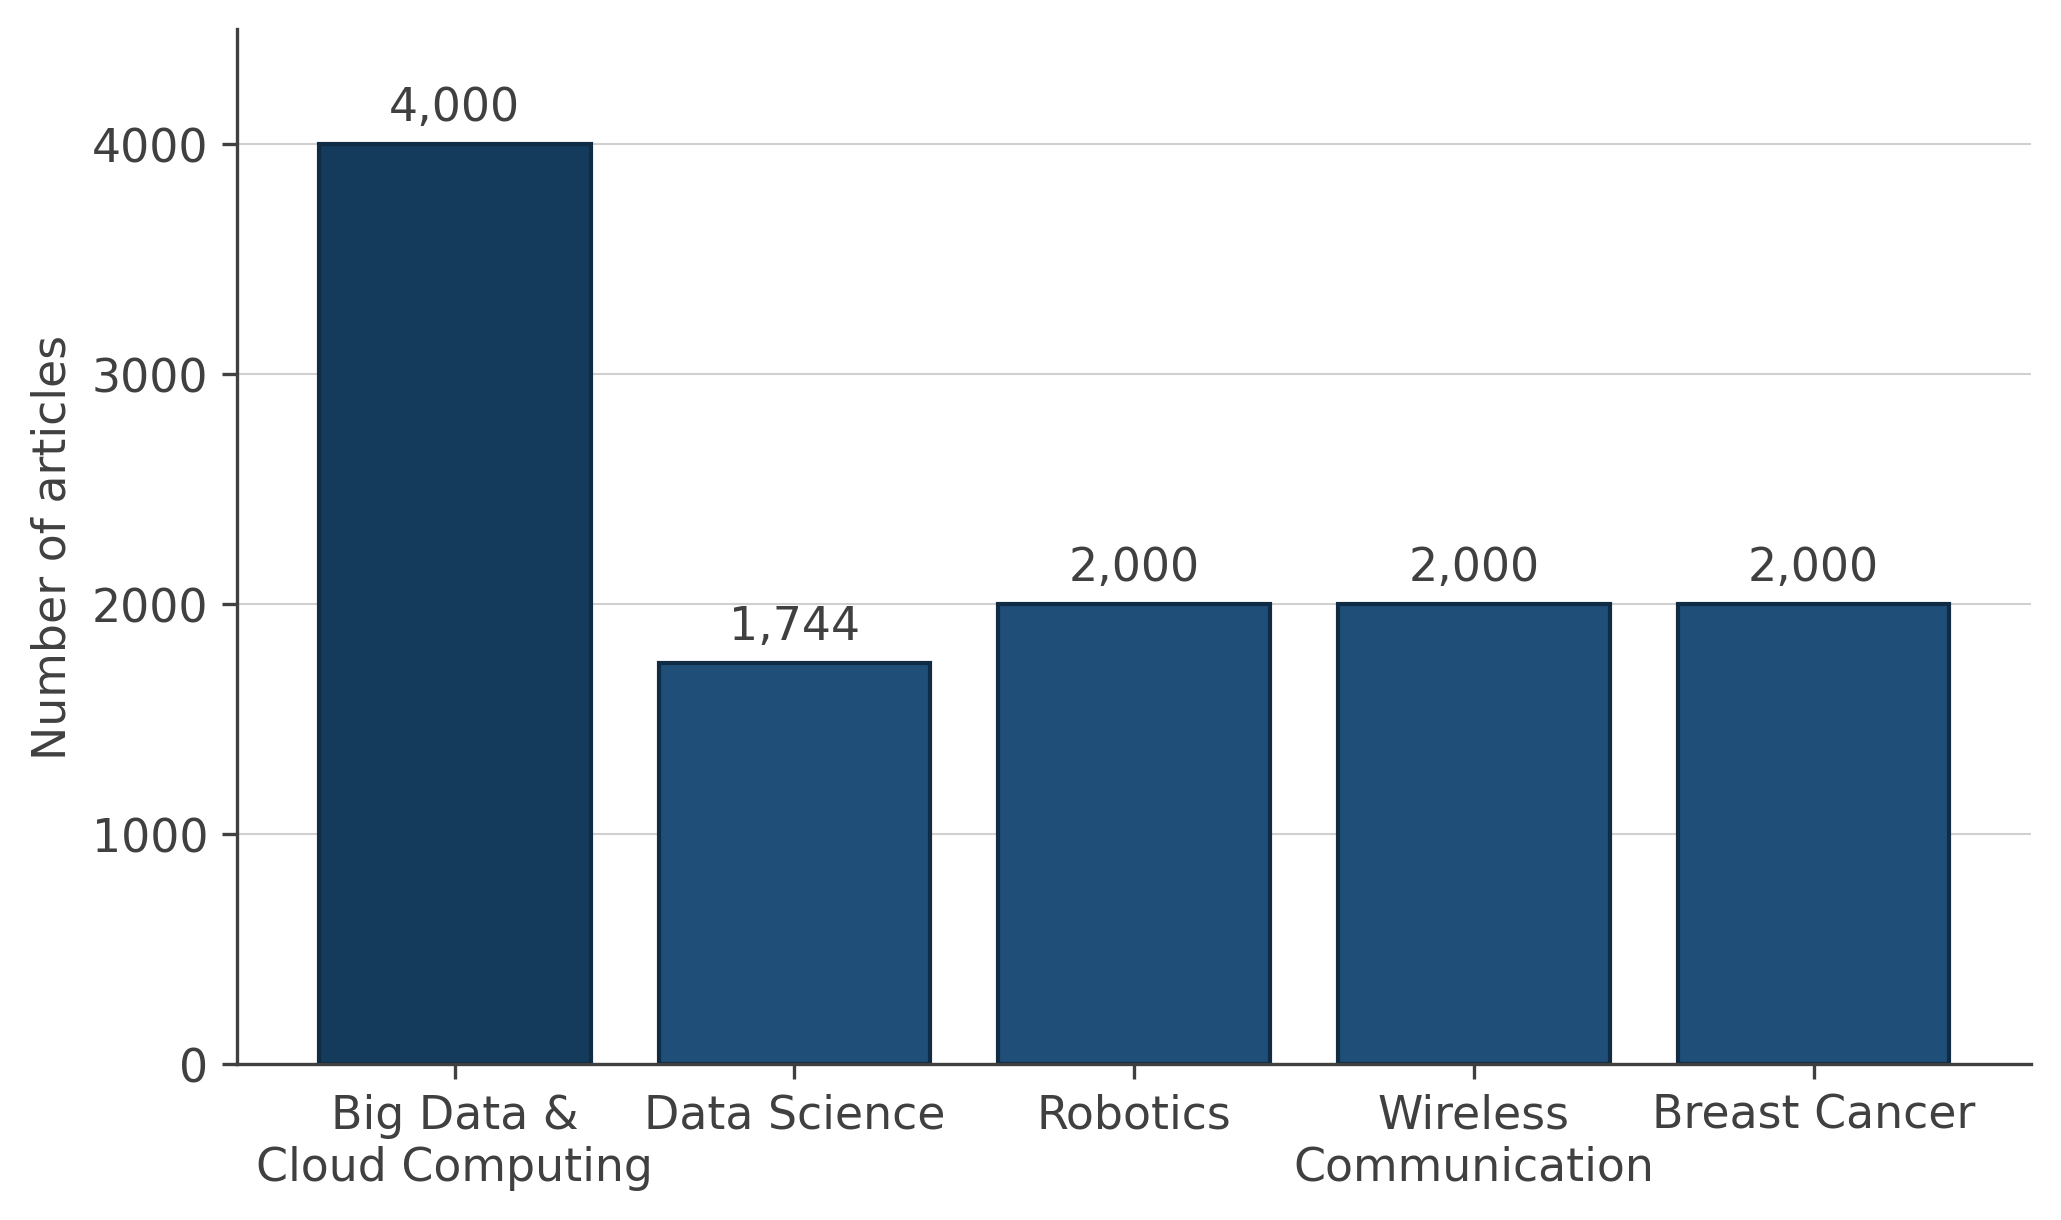

In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#404040",
    "axes.labelcolor": "#404040",
    "xtick.color": "#404040",
    "ytick.color": "#404040",
})

counts = df["Class"].value_counts().sort_index()
class_names = ["Big Data &\nCloud Computing", "Data Science",
               "Robotics", "Wireless\nCommunication", "Breast Cancer"]
colors = ["#143A5C", "#1F4E79", "#1F4E79", "#1F4E79", "#1F4E79"]
# ^ slightly darker shade for the consolidated class

fig, ax = plt.subplots(figsize=(7, 4.2), dpi=300)
bars = ax.bar(class_names, counts.values, color=colors,
              edgecolor="#0F2C44", linewidth=1.0)

# Annotate each bar with its count
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f"{val:,}", ha="center", va="bottom",
            color="#404040", fontsize=11)

ax.set_ylabel("Number of articles")
ax.set_ylim(0, 4500)
ax.set_yticks([0, 1000, 2000, 3000, 4000])
ax.yaxis.grid(True, linestyle="-", linewidth=0.5, color="#D0D0D0", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Figure2.png", dpi=600, bbox_inches="tight")
plt.show()

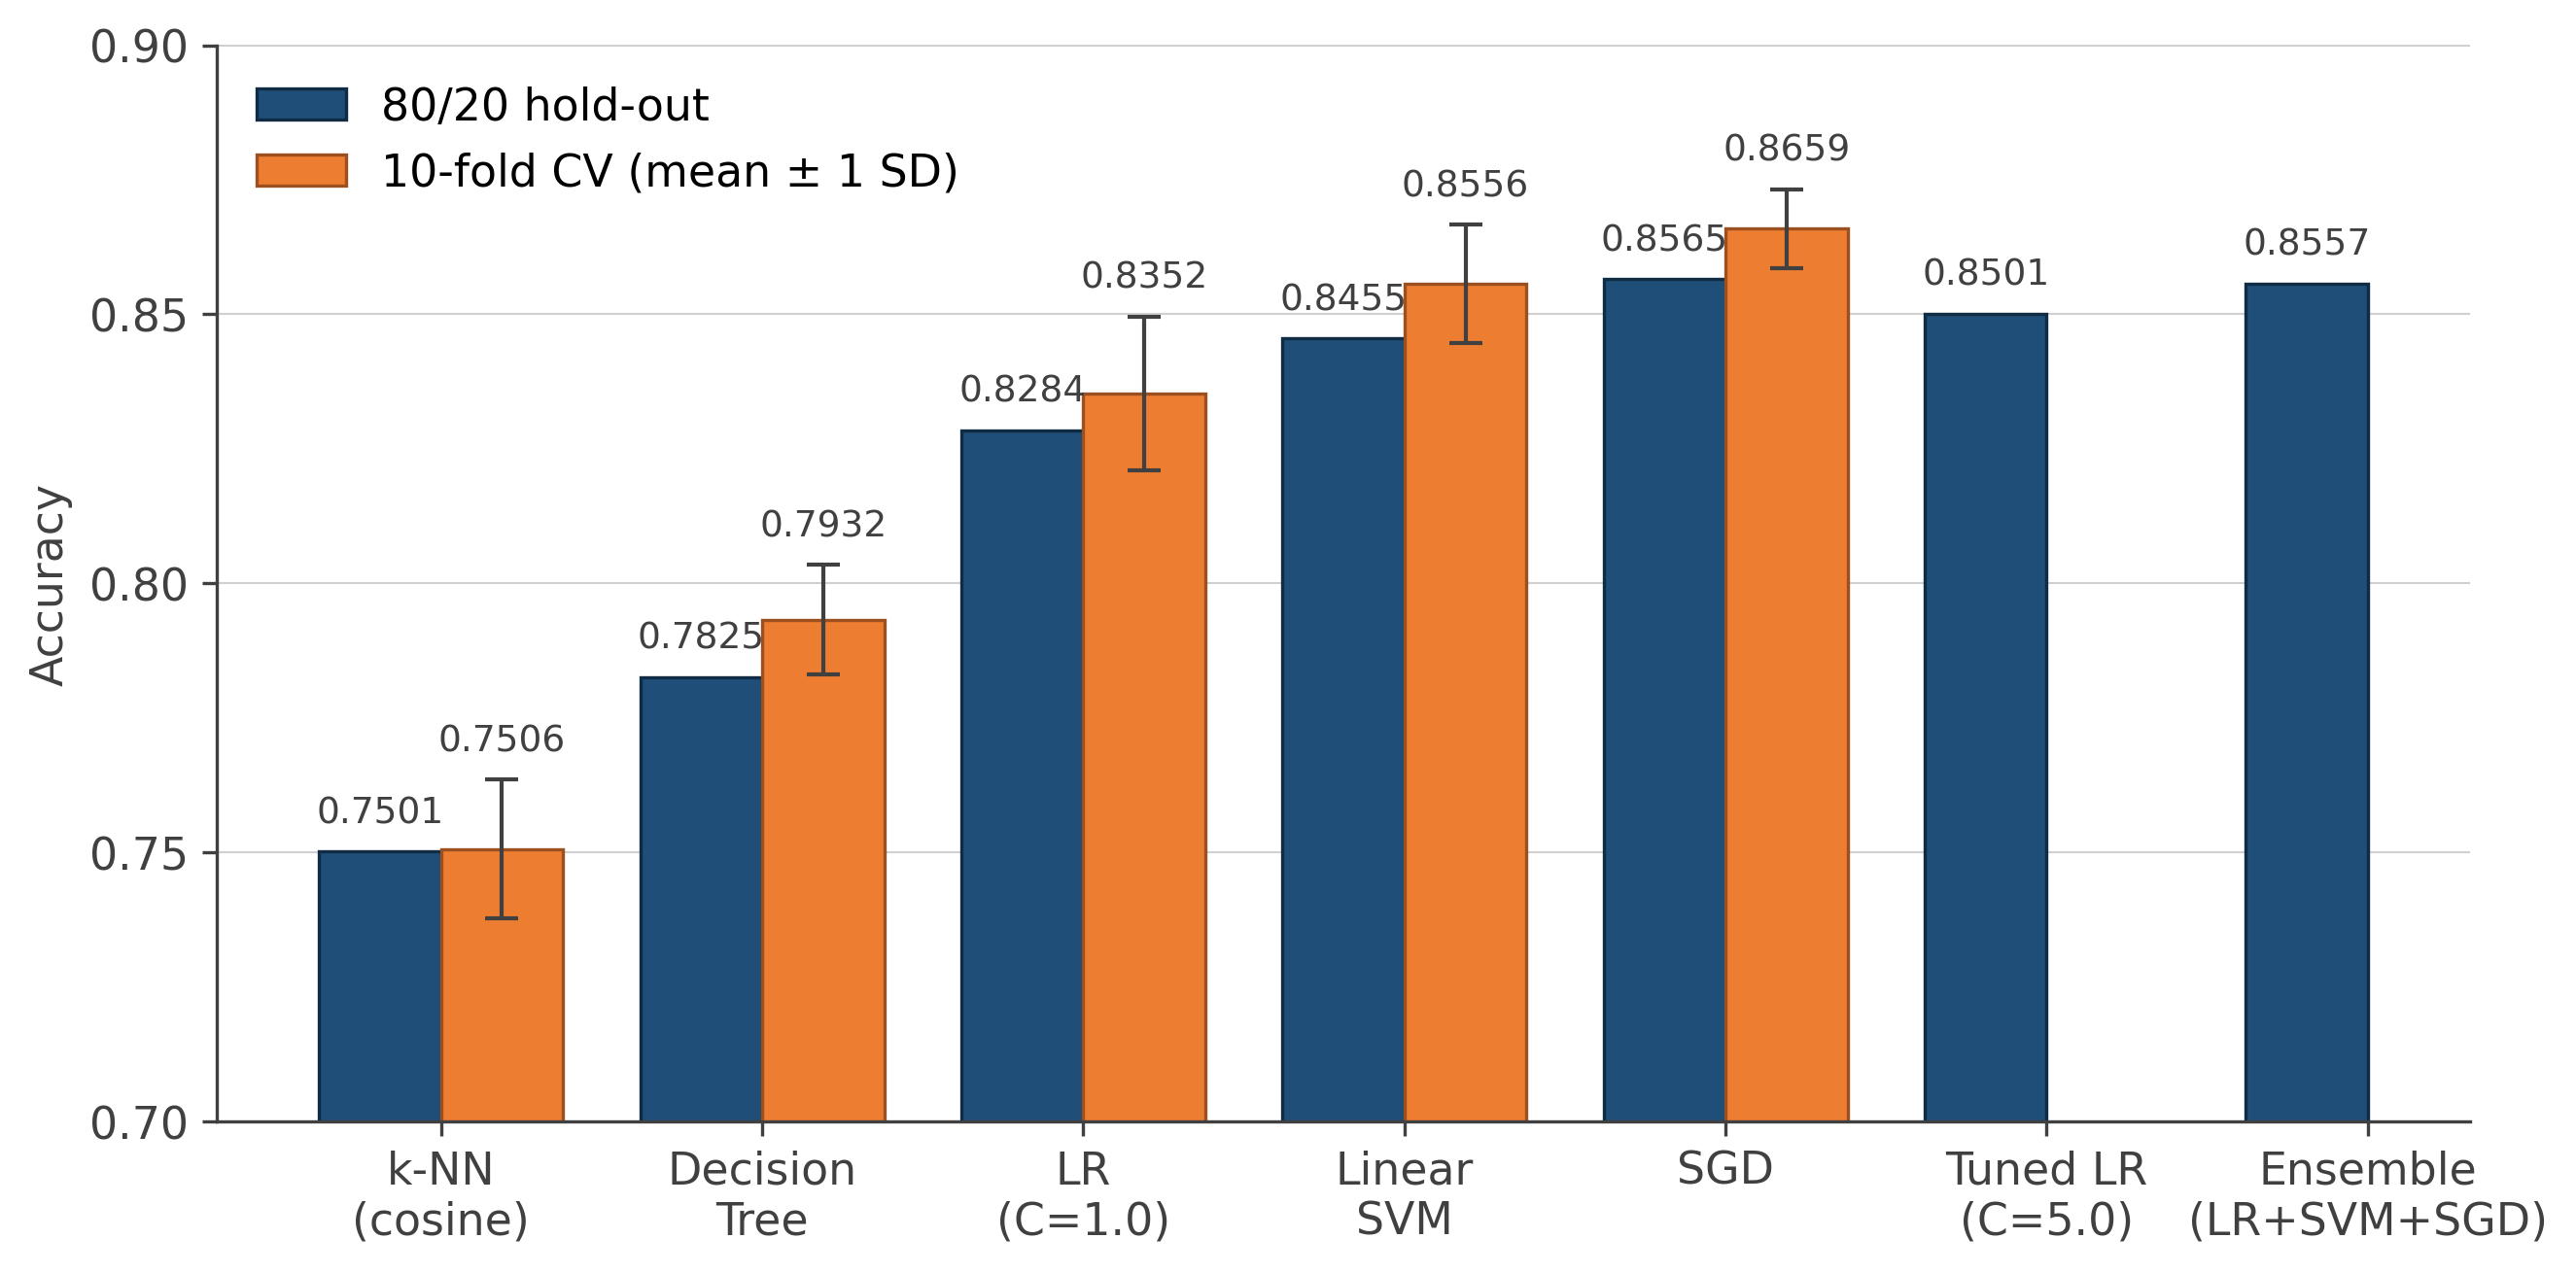

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#404040",
    "axes.labelcolor": "#404040",
    "xtick.color": "#404040",
    "ytick.color": "#404040",
})

classifiers = ["k-NN\n(cosine)", "Decision\nTree", "LR\n(C=1.0)",
               "Linear\nSVM", "SGD", "Tuned LR\n(C=5.0)",
               "Ensemble\n(LR+SVM+SGD)"]
holdout    = [0.7501, 0.7825, 0.8284, 0.8455, 0.8565, 0.8501, 0.8557]
cv_mean    = [0.7506, 0.7932, 0.8352, 0.8556, 0.8659, np.nan, np.nan]
cv_std     = [0.0129, 0.0102, 0.0143, 0.0110, 0.0073, 0.0,    0.0]

x = np.arange(len(classifiers))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=300)

# Hold-out bars (blue)
bars1 = ax.bar(x - w/2, holdout, width=w, color="#1F4E79",
               edgecolor="#0F2C44", linewidth=0.8, label="80/20 hold-out")

# CV bars (orange) with error bars — only first 5 classifiers
cv_x       = x[:5] + w/2
cv_mean_5  = cv_mean[:5]
cv_std_5   = cv_std[:5]
bars2 = ax.bar(cv_x, cv_mean_5, width=w, color="#ED7D31",
               edgecolor="#9C4F1F", linewidth=0.8,
               yerr=cv_std_5, capsize=4, ecolor="#404040",
               error_kw={"linewidth": 1.0},
               label="10-fold CV (mean ± 1 SD)")

# Value labels above bars
for xi, val in zip(x - w/2, holdout):
    ax.text(xi, val + 0.004, f"{val:.4f}", ha="center", va="bottom",
            fontsize=9, color="#404040")
for xi, mn, sd in zip(cv_x, cv_mean_5, cv_std_5):
    ax.text(xi, mn + sd + 0.004, f"{mn:.4f}", ha="center", va="bottom",
            fontsize=9, color="#404040")

ax.set_xticks(x)
ax.set_xticklabels(classifiers)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.70, 0.90)
ax.set_yticks([0.70, 0.75, 0.80, 0.85, 0.90])
ax.yaxis.grid(True, linestyle="-", linewidth=0.5, color="#D0D0D0", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("Figure3.png", dpi=600, bbox_inches="tight")
plt.show()

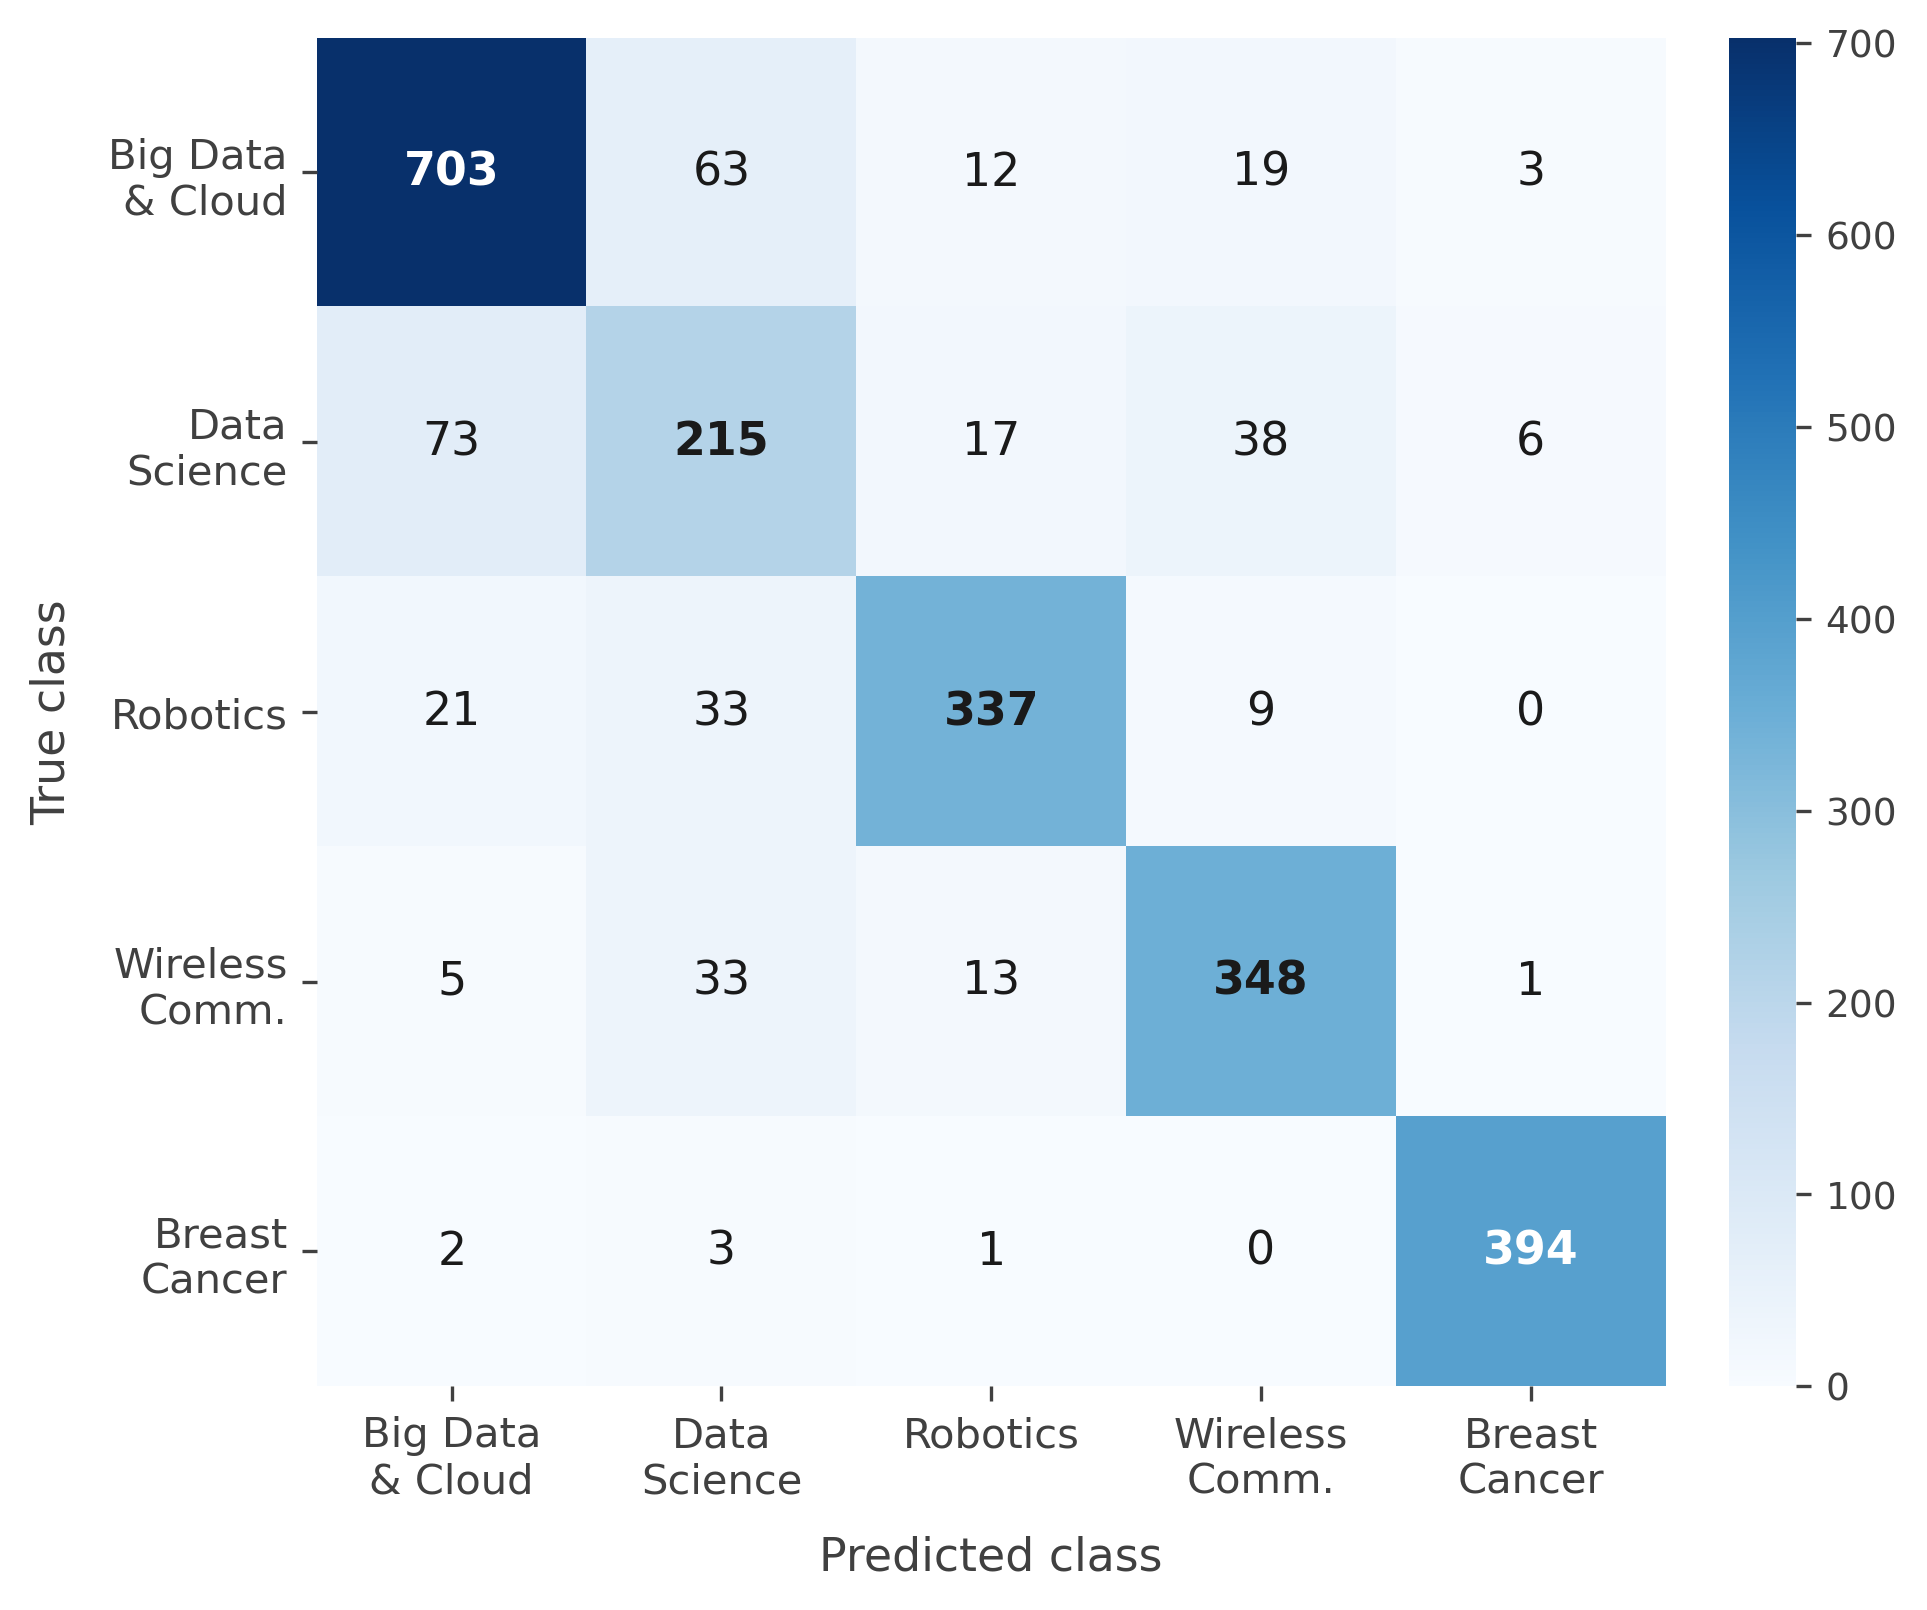

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#404040",
    "axes.labelcolor": "#404040",
    "xtick.color": "#404040",
    "ytick.color": "#404040",
})

# Confusion matrix from the tuned LR run on the held-out test set
cm = np.array([
    [703,  63,  12,  19,   3],
    [ 73, 215,  17,  38,   6],
    [ 21,  33, 337,   9,   0],
    [  5,  33,  13, 348,   1],
    [  2,   3,   1,   0, 394],
])

class_names_short = ["Big Data\n& Cloud", "Data\nScience", "Robotics",
                     "Wireless\nComm.", "Breast\nCancer"]

fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=300)
im = ax.imshow(cm, cmap="Blues", aspect="equal", vmin=0, vmax=cm.max())

# Cell annotations with automatic colour switching
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm[i, j] > threshold else "#1A1A1A"
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color=text_color, fontsize=11,
                fontweight="bold" if i == j else "normal")

# Axis ticks and labels
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(class_names_short, fontsize=10)
ax.set_yticklabels(class_names_short, fontsize=10)
ax.set_xlabel("Predicted class", fontsize=11, labelpad=8)
ax.set_ylabel("True class",      fontsize=11, labelpad=8)
ax.xaxis.set_ticks_position("bottom")

# Hide spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Colour bar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=9, color="#404040")
cbar.outline.set_visible(False)

plt.tight_layout()
plt.savefig("Figure4.png", dpi=600, bbox_inches="tight")
plt.show()


=== Per-class AUC (one-vs-rest, tuned LR) ===
  Big Data & Cloud Computing     AUC = 0.9699
  Data Science                   AUC = 0.9002
  Robotics                       AUC = 0.9801
  Wireless Communication         AUC = 0.9817
  Breast Cancer                  AUC = 0.9991


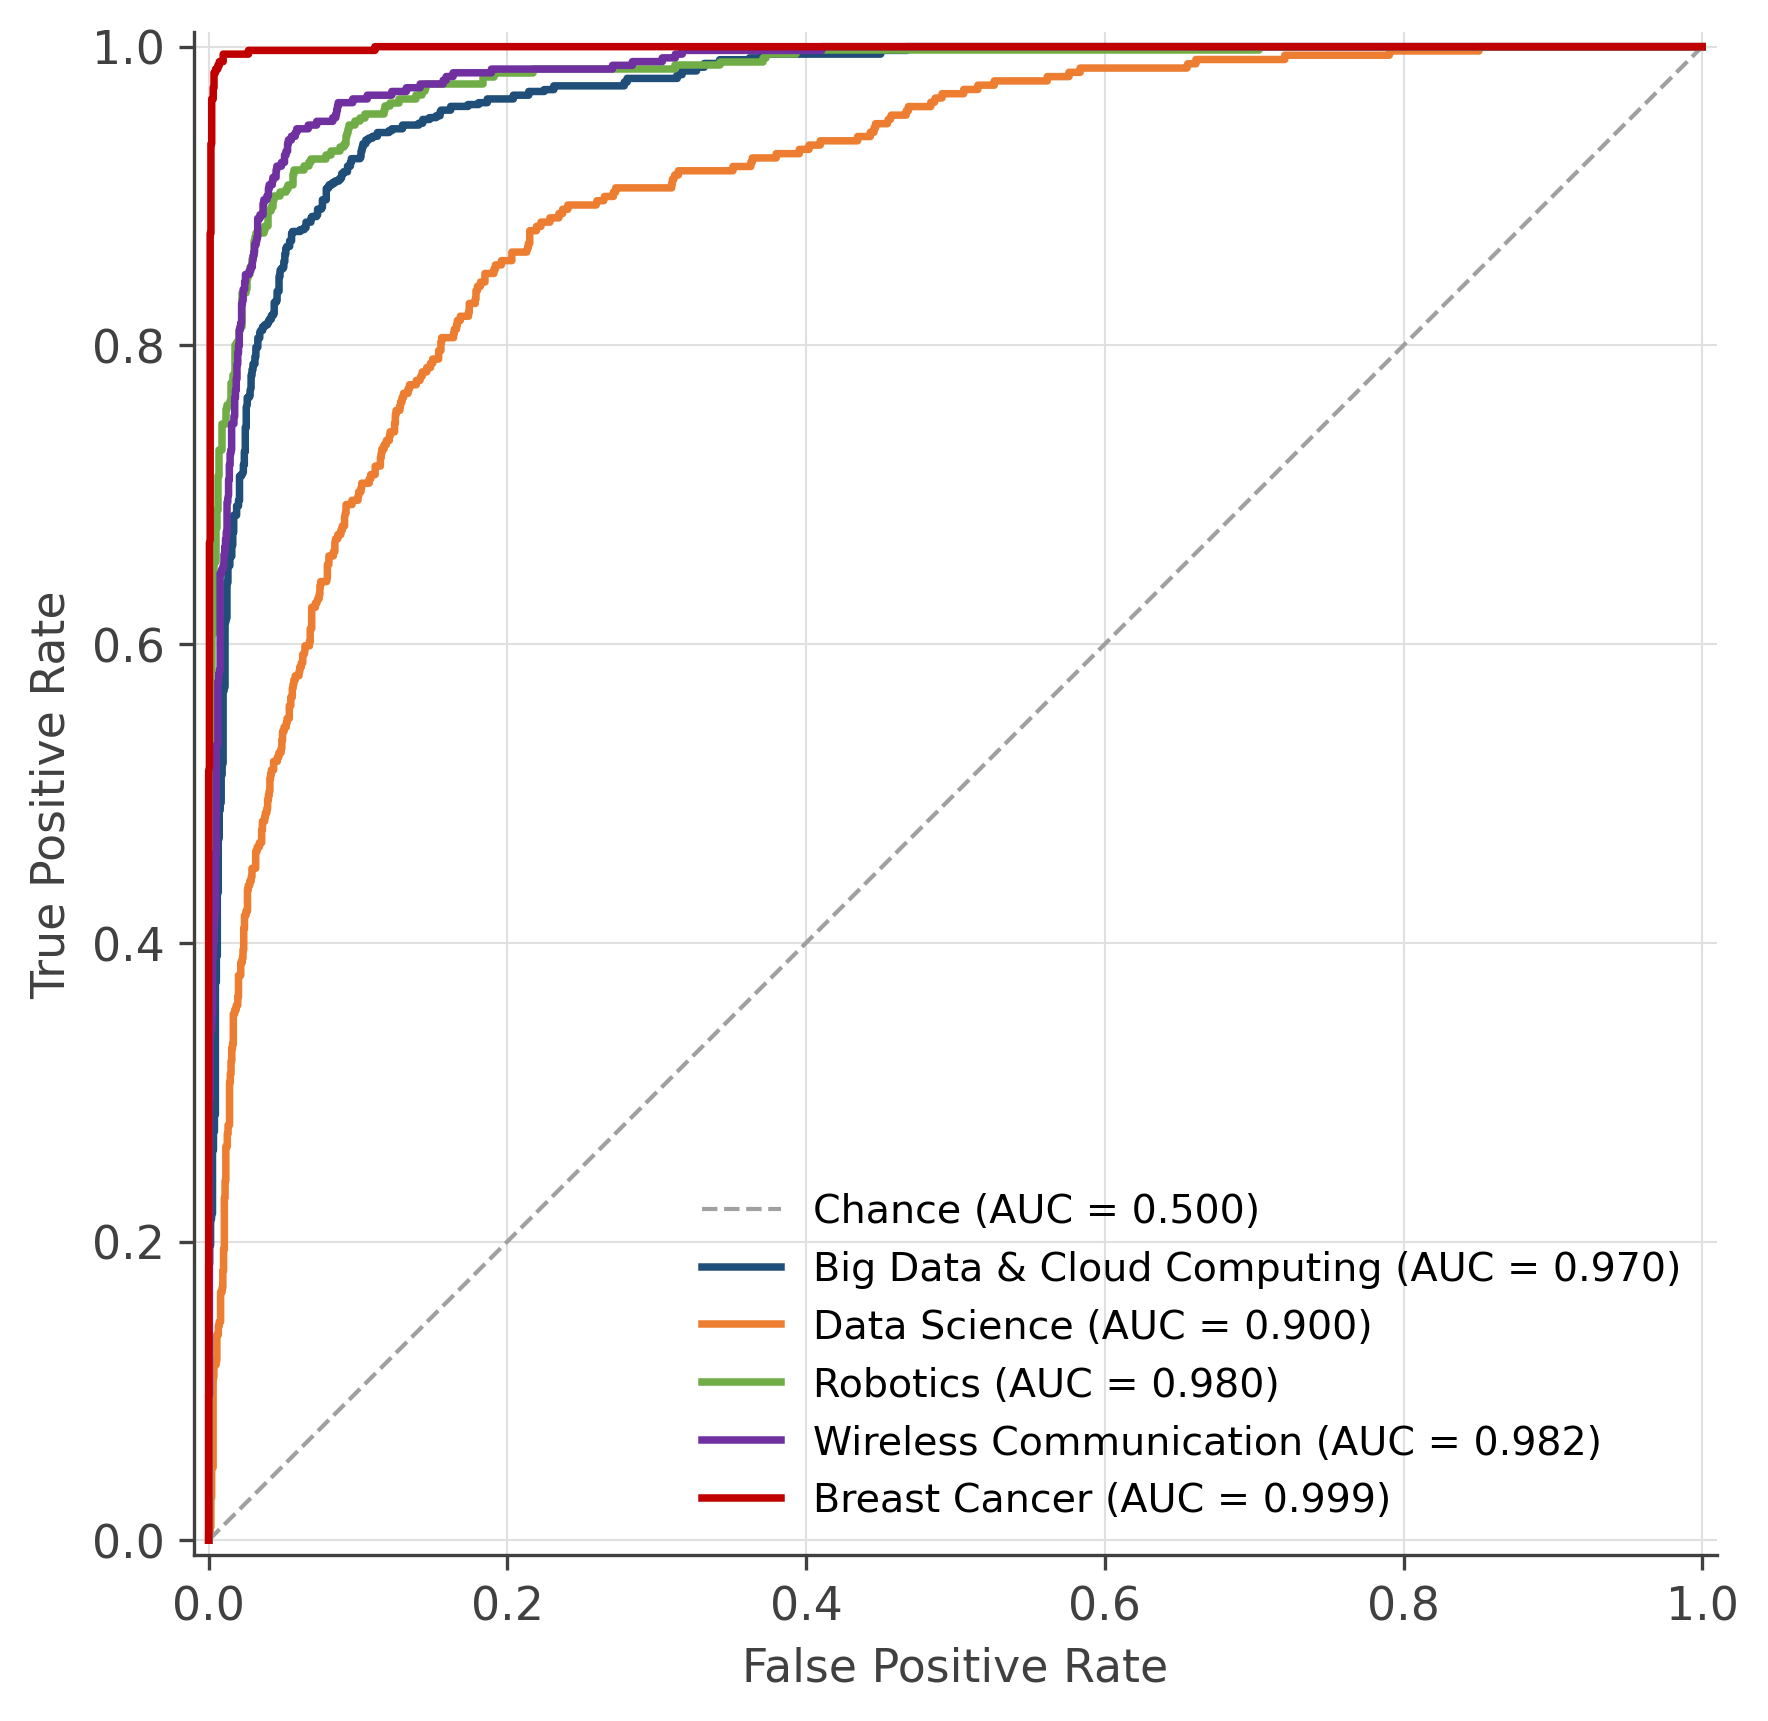

In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#404040",
    "axes.labelcolor": "#404040",
    "xtick.color": "#404040",
    "ytick.color": "#404040",
})

# One-vs-rest binarisation
classes = [0, 1, 2, 3, 4]
y_te_bin = label_binarize(y_te, classes=classes)
y_score  = best_lr.predict_proba(X_te)

# Distinguishable IEEE-friendly colour palette
COLORS = {
    0: "#1F4E79",  # deep blue   - Big Data & Cloud
    1: "#ED7D31",  # orange      - Data Science
    2: "#70AD47",  # green       - Robotics
    3: "#7030A0",  # purple      - Wireless
    4: "#C00000",  # red         - Breast Cancer
}

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# Plot the chance-line first so it sits behind the ROC curves
ax.plot([0, 1], [0, 1], linestyle="--", color="#A0A0A0",
        linewidth=1.0, label="Chance (AUC = 0.500)")

# Compute and plot one ROC curve per class
print("\n=== Per-class AUC (one-vs-rest, tuned LR) ===")
for c in classes:
    fpr, tpr, _ = roc_curve(y_te_bin[:, c], y_score[:, c])
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=COLORS[c], linewidth=1.8,
            label=f"{LABEL_NAMES[c]} (AUC = {a:.3f})")
    print(f"  {LABEL_NAMES[c]:30s} AUC = {a:.4f}")

ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_aspect("equal")
ax.grid(True, linestyle="-", linewidth=0.5, color="#E0E0E0", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", frameon=False, fontsize=9.5)

plt.tight_layout()
plt.savefig("Figure5.png", dpi=600, bbox_inches="tight")
plt.show()